# 02 Exploratory Data Analysis

This notebook explores churn patterns, customer behavior, revenue loss, and key business trends.

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv("../data/processed/cleaned_telco_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag,TenureGroup,MonthlyChargeGroup,RevenueSegment
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0-12 Months,Low,Low Value
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,One year,No,Mailed check,56.95,1889.50,No,0,25-48 Months,Medium,Medium Value
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0-12 Months,Medium,Low Value
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,25-48 Months,Medium,Medium Value
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0-12 Months,High,Low Value


## Overall Churn Rate

In [29]:
total_customers = df.shape[0]
churned_customers = df[df["Churn"] == "Yes"].shape[0]
churn_rate = churned_customers / total_customers * 100

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print(f"Churn Rate: {churn_rate:.2f}%")

Total Customers: 7043
Churned Customers: 1869
Churn Rate: 26.54%


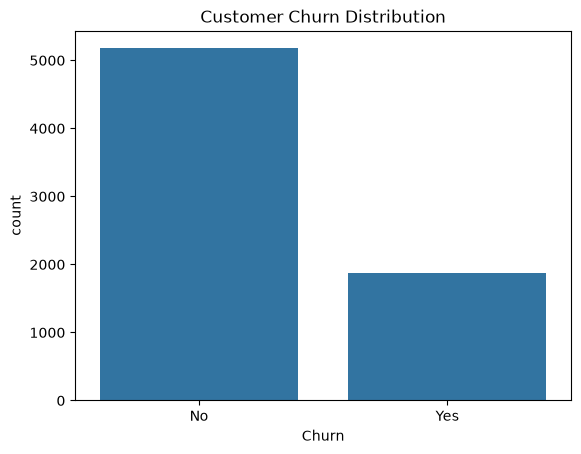

In [30]:
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.show()

## Churn by Contract Type

In [31]:
contract_churn = df.groupby("Contract")["ChurnFlag"].mean().sort_values(ascending=False) * 100
contract_churn

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: ChurnFlag, dtype: float64

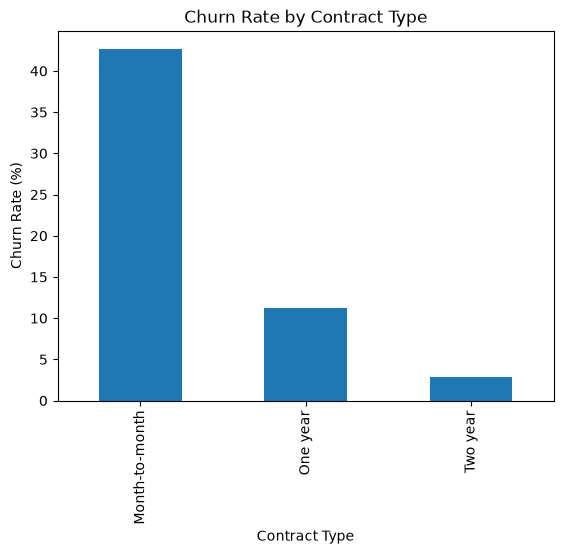

In [32]:
contract_churn.plot(kind="bar")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Contract Type")
plt.show()

## Churn by Internet Service

In [33]:
internet_churn = df.groupby("InternetService")["ChurnFlag"].mean().sort_values(ascending=False) * 100
internet_churn

InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: ChurnFlag, dtype: float64

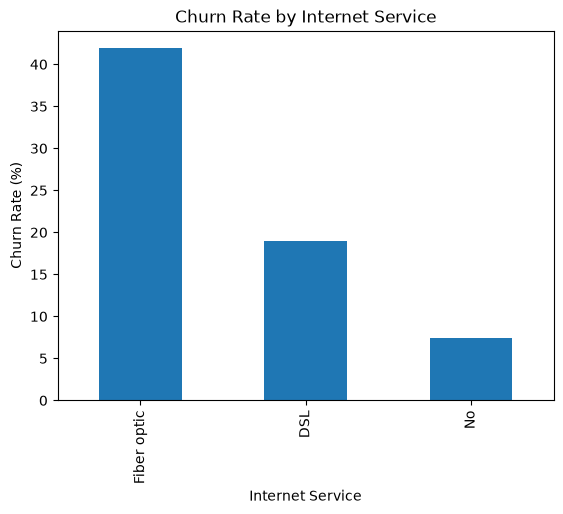

In [34]:
internet_churn.plot(kind="bar")
plt.title("Churn Rate by Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Internet Service")
plt.show()

## Churn by Payment Method

In [35]:
payment_churn = df.groupby("PaymentMethod")["ChurnFlag"].mean().sort_values(ascending=False) * 100
payment_churn

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: ChurnFlag, dtype: float64

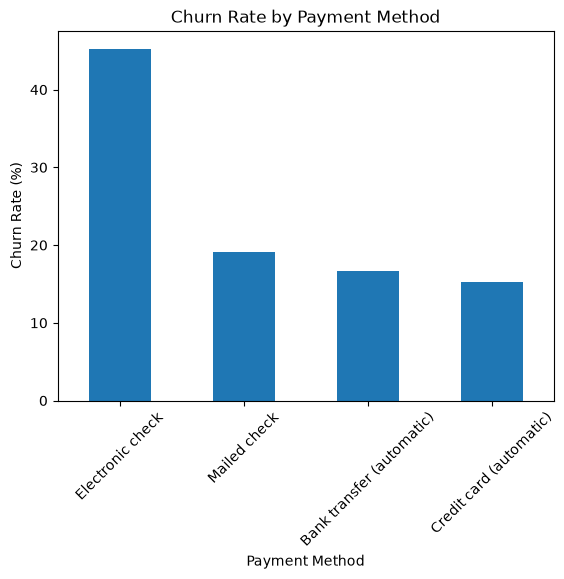

In [36]:
payment_churn.plot(kind="bar")
plt.title("Churn Rate by Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Payment Method")
plt.xticks(rotation=45)
plt.show()

## Monthly Charges by Churn

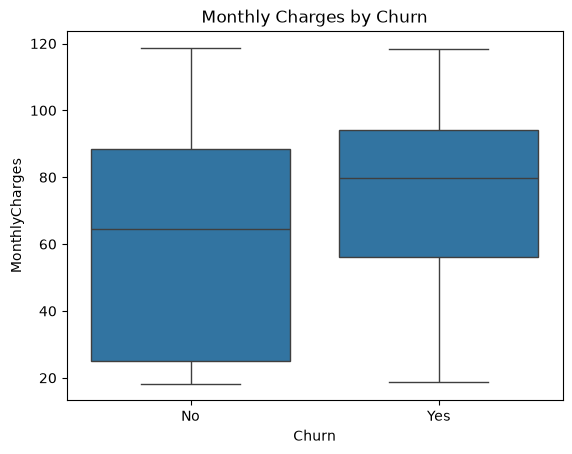

In [37]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn")
plt.show()

## Tenure by Churn

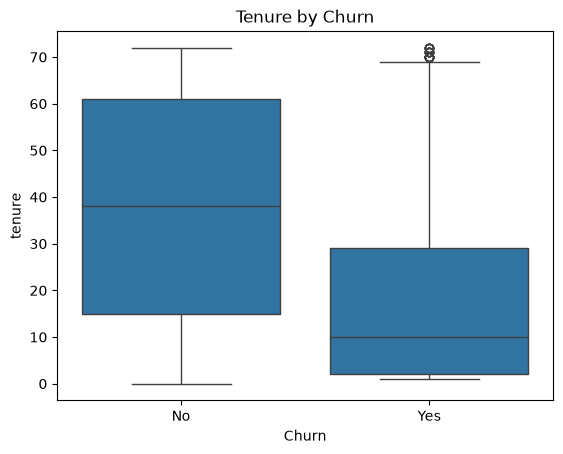

In [38]:
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure by Churn")
plt.show()

## Revenue Loss Due to Churn

In [39]:
monthly_revenue_lost = df[df["Churn"] == "Yes"]["MonthlyCharges"].sum()
total_monthly_revenue = df["MonthlyCharges"].sum()
revenue_loss_pct = monthly_revenue_lost / total_monthly_revenue * 100

print(f"Monthly Revenue Lost: ${monthly_revenue_lost:,.2f}")
print(f"Total Monthly Revenue: ${total_monthly_revenue:,.2f}")
print(f"Revenue Loss Percentage: {revenue_loss_pct:.2f}%")

Monthly Revenue Lost: $139,130.85
Total Monthly Revenue: $456,116.60
Revenue Loss Percentage: 30.50%


## Correlation Analysis

In [40]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "ChurnFlag"]

corr = df[numeric_cols].corr()
corr

,tenure,MonthlyCharges,TotalCharges,ChurnFlag
tenure,1.000000,0.247900,0.825464,-0.352229
MonthlyCharges,0.247900,1.000000,0.650864,0.193356
TotalCharges,0.825464,0.650864,1.000000,-0.199037
ChurnFlag,-0.352229,0.193356,-0.199037,1.000000


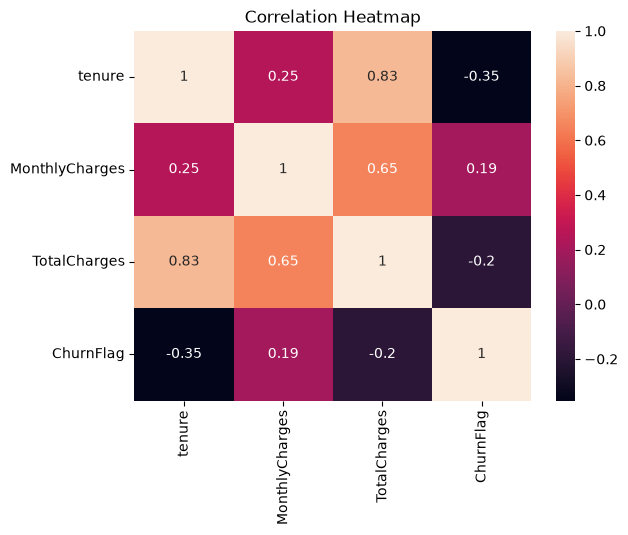

In [41]:
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()